# MVP Análise de Dados e Boas Práticas - EmoPiano

**Autor:** Ricardo Fernandes de Almeida<br>
**Disciplina: Sprint - Análise de Dados e Boas Práticas (MVP)**<br>
**Data:** Abril 2026<br>
**Especialização em Ciência de Dados - PUC Rio**


**Dataset:** [EmoPiano: Dataset for Emotion Recognition in Piano](https://www.kaggle.com/datasets/ziya07/emopiano-dataset-for-emotion-recognition-in-piano)

# Descrição do Problema

O conjunto de dados EmoPiano foi projetado para o reconhecimento de emoções em composições de piano. Ele contém diversas características musicais e emocionais, tornando-o um recurso ideal para análise de sentimentos em musicologia computacional e tarefas de detecção de emoção assistida por IA. O objetivo principal é classificar a emoção de uma peça de piano (feliz, triste, com raiva, relaxada) com base em suas características extraídas.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **As diferentes emoções podem ser distinguidas com base nas características musicais como tempo, `dynamic_range`, e `MFCCs`?**

2. **Existe uma correlação entre as características de áudio (`MFCCs`, `Chroma`) e os indicadores de emoção `valence` e `arousal`?**

3. **Composições com andamento (`tempo`) mais rápido tendem a ser classificadas como 'feliz' ou 'com raiva', enquanto as mais lentas são 'tristes' ou 'relaxadas'?**

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características musicais, o objetivo é prever a qual das quatro classes de emoção uma determinada composição de piano pertence.

## Seleção de Dados

O dataset `piano_dataset.csv` foi fornecido e será carregado diretamente. Ele contém 200 amostras de composições de piano.

## Atributos do Dataset

O dataset EmoPiano contém 200 amostras e 31 atributos:

- **`tempo`**: O andamento da composição em BPM.
- **`dynamic_range`**: A faixa de intensidade da peça.
- **`emotion`**: A categoria emocional anotada (feliz, triste, com raiva, relaxada).
- **`valence`**: Positividade ou negatividade emocional (-1 a 1).
- **`arousal`**: Intensidade emocional (-1 a 1).
- **`mfcc_1` a `mfcc_13`**: 13 coeficientes cepstrais de frequência Mel que capturam informações tonais.
- **`chroma_1` a `chroma_12`**: 12 características de croma que representam a intensidade das 12 classes de notas.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset EmoPiano.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
# carregamento do dataset
#df = pd.read_csv('piano_dataset.csv')

url = "https://raw.githubusercontent.com/ricferal/disciplina_visualizar_dados/main/piano_dataset_with_target.csv"

df_piano = pd.read_csv(url)
df = df_piano

In [5]:
# primeiras linhas
df.head()

,tempo,dynamic_range,emotion,target,valence,arousal,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,chroma_3,chroma_4,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12
0,185,8.974430,angry,2,-0.136165,-0.823266,-1.560871,1.818751,-0.519439,-0.682006,...,0.586204,0.505213,0.658876,0.309927,0.099292,0.725223,0.653599,0.478684,0.668415,0.525005
1,189,5.721294,relaxed,3,0.636710,-0.040309,-1.746703,-0.311389,0.912605,0.465032,...,0.632383,0.125726,0.606965,0.640758,0.413828,0.378064,0.162822,0.641440,0.175389,0.128902
2,153,10.495791,angry,2,0.181768,0.251954,-1.930588,-1.540567,0.481840,-0.211247,...,0.283249,0.171096,0.583925,0.727312,0.087699,0.421187,0.994488,0.676111,0.186657,0.787938
3,78,13.850276,relaxed,3,-0.491581,-0.338365,-0.792529,-0.584589,1.129157,-0.249985,...,0.329692,0.331596,0.527783,0.222771,0.208732,0.289438,0.942407,0.591868,0.909312,0.119276
4,70,11.853227,happy,0,-0.354578,-0.880542,-0.501304,-0.457626,-2.156041,-0.274304,...,0.766772,0.172471,0.697273,0.465019,0.557789,0.618534,0.718594,0.717522,0.608643,0.192297


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset EmoPiano, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset EmoPiano possui 200 instâncias. As características são numéricas (float), enquanto o atributo 'emotion' é categórico.

In [6]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
df.info()

Total de instâncias: 200

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 31 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tempo          200 non-null    int64  
 1   dynamic_range  200 non-null    float64
 2   emotion        200 non-null    object 
 3   target         200 non-null    int64  
 4   valence        200 non-null    float64
 5   arousal        200 non-null    float64
 6   mfcc_1         200 non-null    float64
 7   mfcc_2         200 non-null    float64
 8   mfcc_3         200 non-null    float64
 9   mfcc_4         200 non-null    float64
 10  mfcc_5         200 non-null    float64
 11  mfcc_6         200 non-null    float64
 12  mfcc_7         200 non-null    float64
 13  mfcc_8         200 non-null    float64
 14  mfcc_9         200 non-null    float64
 15  mfcc_10        200 non-null    float64
 16  mfcc_11        200 non-null    float64
 17  m

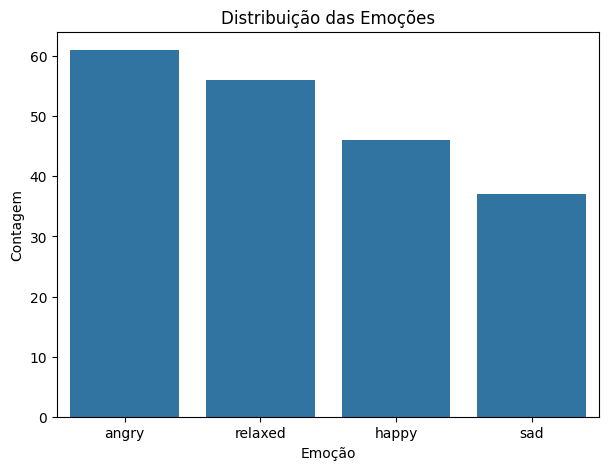

In [7]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='emotion', data=df)
plt.title('Distribuição das Emoções')
plt.xlabel('Emoção')
plt.ylabel('Contagem')
plt.show()

O gráfico de barras mostra que cada emoção possui 50 amostras, confirmando que o dataset é balanceado em termos de classes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas.

In [8]:
# estatísticas descritivas básicas do dataset
df.describe()

,tempo,dynamic_range,target,valence,arousal,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,chroma_3,chroma_4,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,120.950000,12.417481,1.635000,-0.009503,-0.052497,0.012425,-0.027230,0.068157,0.052529,0.078391,...,0.521264,0.507574,0.462589,0.501514,0.505521,0.499028,0.504082,0.460032,0.486656,0.466942
std,43.816285,4.568105,1.121635,0.547535,0.556913,1.125990,1.019354,1.095894,1.044533,1.022015,...,0.307924,0.270503,0.269638,0.292173,0.282189,0.286350,0.299698,0.271986,0.274106,0.293655
min,41.000000,5.059204,0.000000,-0.998151,-0.995030,-2.728790,-2.607533,-3.060763,-3.572304,-2.755168,...,0.004012,0.018317,0.002268,0.000725,0.000764,0.003509,0.001036,0.009770,0.019128,0.000816
25%,85.750000,8.762525,1.000000,-0.475846,-0.541312,-0.780503,-0.692033,-0.574702,-0.633548,-0.711662,...,0.264399,0.283279,0.237718,0.254259,0.266090,0.250579,0.240336,0.213520,0.244628,0.226042
50%,120.000000,11.985872,2.000000,-0.020507,-0.051069,0.026875,-0.142620,0.155895,-0.022213,0.069309,...,0.545633,0.499070,0.458218,0.494158,0.525451,0.512490,0.497097,0.448643,0.503443,0.441859
75%,155.250000,16.354463,3.000000,0.481416,0.392714,0.809371,0.716648,0.807568,0.686120,0.823738,...,0.818211,0.738121,0.685630,0.738611,0.741312,0.726497,0.785776,0.685696,0.720379,0.730327
max,200.000000,19.950339,3.000000,0.998030,0.971172,3.214893,2.963413,3.098886,3.026462,3.279157,...,0.999277,0.992081,0.995647,0.991705,0.999110,0.999415,0.994488,0.996644,0.997770,0.988745


## Histograma

Vamos analisar a distribuição de algumas características importantes.

### `tempo`

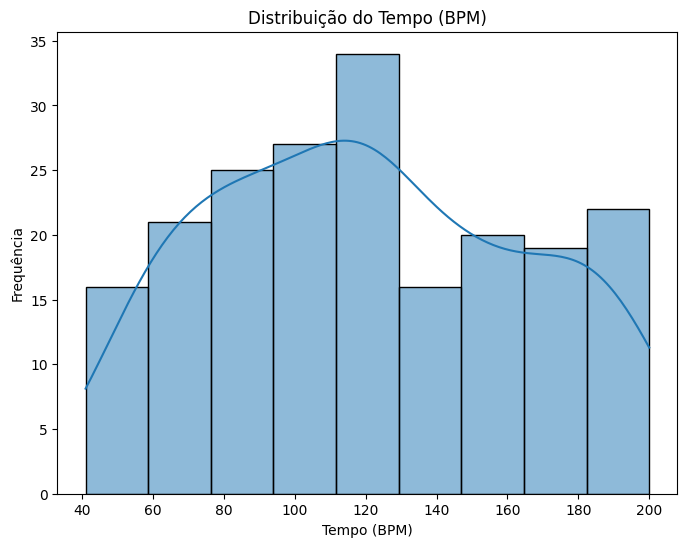

In [9]:
plt.figure(figsize=(8, 6))
sns.histplot(df['tempo'], kde=True)
plt.title('Distribuição do Tempo (BPM)')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Frequência')
plt.show()

O histograma do `tempo` mostra a distribuição do andamento das composições no dataset.

### `dynamic_range`

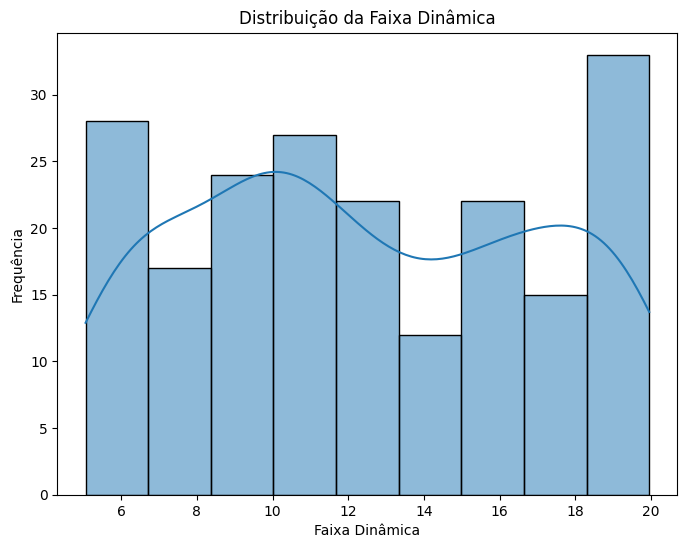

In [10]:
plt.figure(figsize=(8, 6))
sns.histplot(df['dynamic_range'], kde=True)
plt.title('Distribuição da Faixa Dinâmica')
plt.xlabel('Faixa Dinâmica')
plt.ylabel('Frequência')
plt.show()

## Boxplot

Para entender as diferenças entre as emoções, vamos agrupar por `emotion`.

In [11]:
# Estatísticas descritivas agrupadas por emoção
df.groupby('emotion').describe()

tempo                                                           \
        count        mean        std   min    25%    50%    75%    max   
emotion                                                                  
angry    61.0  129.852459  40.407027  55.0  105.0  124.0  162.0  200.0   
happy    46.0  123.652174  41.526012  44.0   89.0  119.5  152.5  200.0   
relaxed  56.0  117.428571  45.994014  41.0   78.0  115.0  153.5  199.0   
sad      37.0  108.243243  46.637732  41.0   66.0  107.0  141.0  198.0   

        dynamic_range             ... chroma_11           chroma_12            \
                count       mean  ...       75%       max     count      mean   
emotion                           ...                                           
angry            61.0  12.536792  ...  0.717357  0.986864      61.0  0.451849   
happy            46.0  12.857443  ...  0.698999  0.928187      46.0  0.526441   
relaxed          56.0  12.011183  ...  0.729760  0.996112      56.0  0.424668   
sad              37.0  12.288738  ...  0.730368  0.997770      37.0  0.481835   

                                                                     
              std       min       25%       50%       75%       max  
emotion                                                              
angry    0.299257  0.000816  0.232530  0.391005  0.730326  0.988745  
happy    0.274159  0.016269  0.296545  0.540010  0.771523  0.938693  
relaxed  0.310417  0.014352  0.128541  0.379812  0.680689  0.932042  
sad      0.279882  0.003770  0.307623  0.478049  0.722578  0.942412  

[4 rows x 240 columns]

### `valence` por Emoção

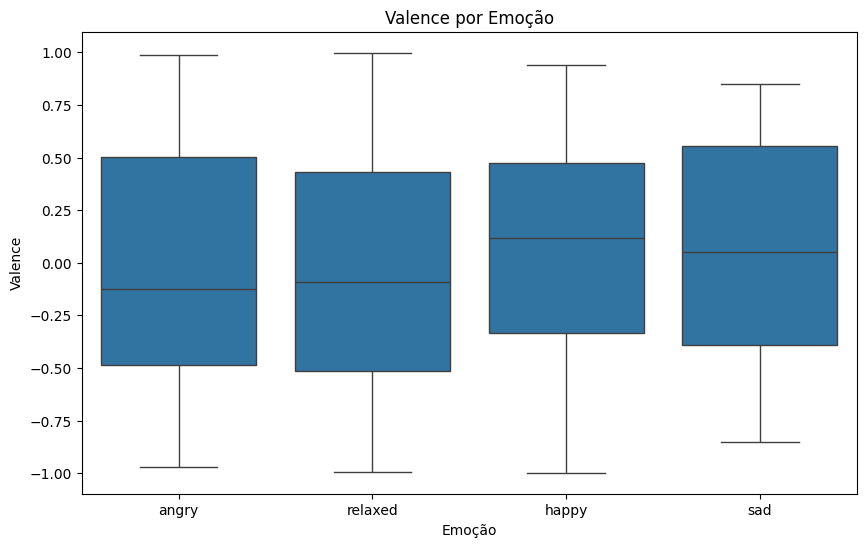

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='emotion', y='valence', data=df)
plt.title('Valence por Emoção')
plt.xlabel('Emoção')
plt.ylabel('Valence')
plt.show()

O boxplot de `valence` por emoção pode nos dar uma ideia de como a positividade/negatividade da música varia entre as emoções.

### `arousal` por Emoção

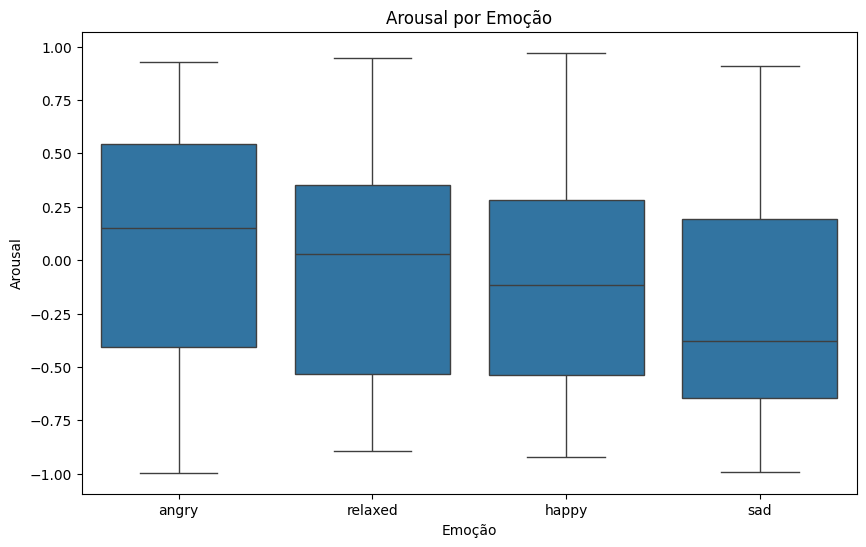

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='emotion', y='arousal', data=df)
plt.title('Arousal por Emoção')
plt.xlabel('Emoção')
plt.ylabel('Arousal')
plt.show()

O boxplot de `arousal` mostra a intensidade emocional para cada categoria.

## Matriz de Correlação

A matriz de correlação nos ajuda a entender as relações lineares entre os atributos numéricos.

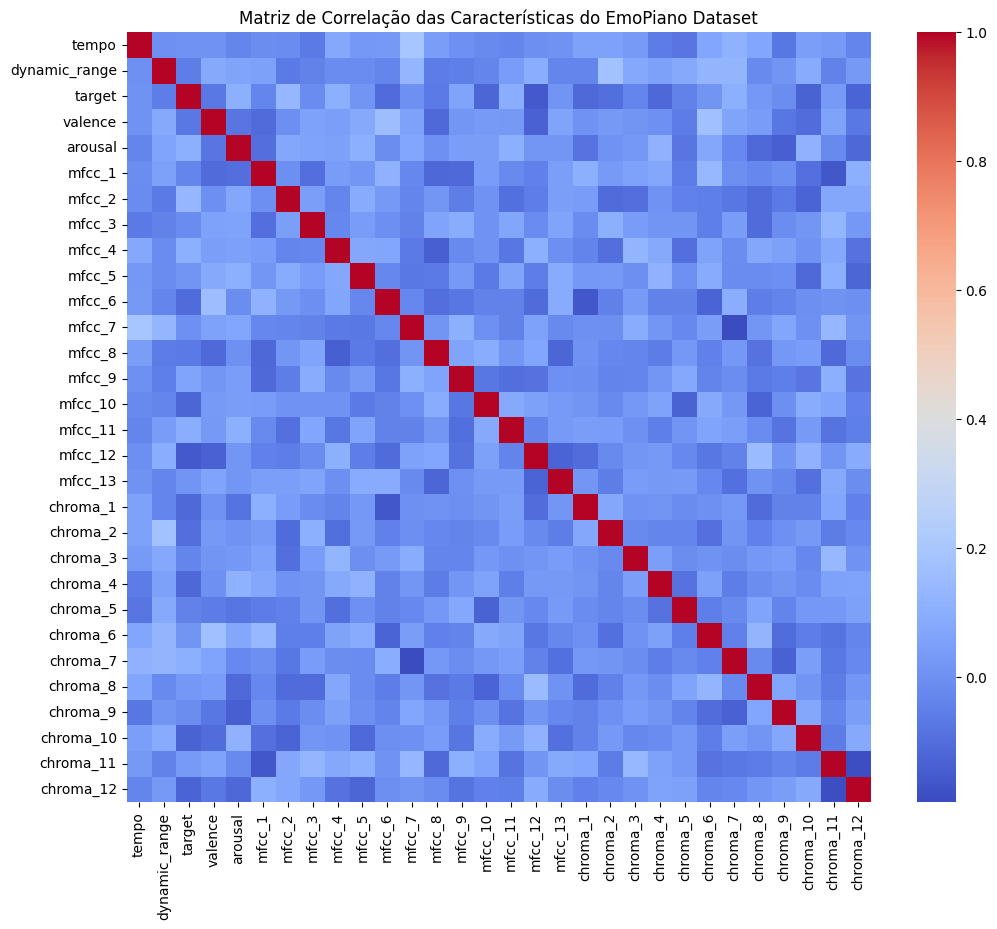

In [14]:
# Matriz de correlação
plt.figure(figsize=(12, 10))
correlation_matrix = df.drop('emotion', axis=1).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Matriz de Correlação das Características do EmoPiano Dataset')
plt.show()

Devido ao grande número de features, a visualização completa pode ser densa. Focaremos nas correlações com `valence` e `arousal`.

In [15]:
print(correlation_matrix[['valence', 'arousal']])

                valence   arousal
tempo          0.007062 -0.034538
dynamic_range  0.081986  0.062624
target        -0.069810  0.102951
valence        1.000000 -0.082713
arousal       -0.082713  1.000000
mfcc_1        -0.106841 -0.097551
mfcc_2        -0.003769  0.072282
mfcc_3         0.056772  0.057262
mfcc_4         0.045643  0.051406
mfcc_5         0.081849  0.100370
mfcc_6         0.156728 -0.010036
mfcc_7         0.055124  0.070531
mfcc_8        -0.113526 -0.001492
mfcc_9         0.015613  0.040660
mfcc_10        0.033639  0.042510
mfcc_11        0.028659  0.103796
mfcc_12       -0.134615  0.016568
mfcc_13        0.063465  0.015194
chroma_1       0.008499 -0.084008
chroma_2       0.026876  0.008947
chroma_3       0.011458  0.021616
chroma_4      -0.002468  0.110450
chroma_5      -0.061447 -0.078602
chroma_6       0.169938  0.073354
chroma_7       0.064556 -0.022768
chroma_8       0.037071 -0.113696
chroma_9      -0.075782 -0.142911
chroma_10     -0.104194  0.110087
chroma_11     

## Tratamento de Valores Nulos

Verificando se existem valores nulos no dataset.

In [16]:
print("Valores nulos no dataset EmoPiano:")
df.isnull().sum()

Valores nulos no dataset EmoPiano:


,0
tempo,0
dynamic_range,0
emotion,0
target,0
valence,0
arousal,0
mfcc_1,0
mfcc_2,0
mfcc_3,0
mfcc_4,0


O dataset não possui valores nulos.

# Pré-Processamento de Dados

In [17]:
# Separar features (X) e target (y)
X = df.drop('emotion', axis=1)
y = df['emotion']

# Codificar a variável alvo
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [18]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

In [19]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (140, 30)
Dimensões de X_test: (60, 30)
Dimensões de y_train: (140,)
Dimensões de y_test: (60,)


## Padronização

In [20]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

# Exibir as primeiras linhas dos dados padronizados
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
      tempo  dynamic_range    target   valence   arousal    mfcc_1    mfcc_2  \
0 -1.373920      -1.374700  0.326367  0.974473 -1.073610  1.093091 -0.465917   
1 -0.532380       1.430145  0.326367 -1.613674  1.154123 -0.795973 -1.133932   
2  1.127956      -0.274305  0.326367 -0.546973  1.091091 -1.168103 -1.401184   
3  0.149950       1.251936 -1.465452  0.234002 -0.009931 -0.755235 -0.224451   
4 -1.055499      -1.044950  0.326367 -0.331466 -0.204321 -0.652491 -0.931504   

     mfcc_3    mfcc_4    mfcc_5  ...  chroma_3  chroma_4  chroma_5  chroma_6  \
0 -0.404887  0.945696  1.369490  ... -0.786303 -0.675212  0.095424 -0.819434   
1  1.570967 -0.492329 -0.305295  ... -1.535061 -0.412938  1.859624 -0.166430   
2 -0.686035  0.524275 -0.531143  ... -0.722546 -1.720028  0.070309 -1.062876   
3  0.865307 -1.001203 -0.023425  ...  1.553676  1.764863 -0.494344  1.004286   
4  1.360078  0.471043  1.036436  ...  0.119645 -0.748825  0.352341

# Respondendo nossas hipóteses

## Hipótese 1: As diferentes emoções podem ser distinguidas com base nas características musicais como tempo, `dynamic_range`, e `MFCCs`?

Os boxplots de `tempo` e `dynamic_range` por emoção podem nos dar uma pista.

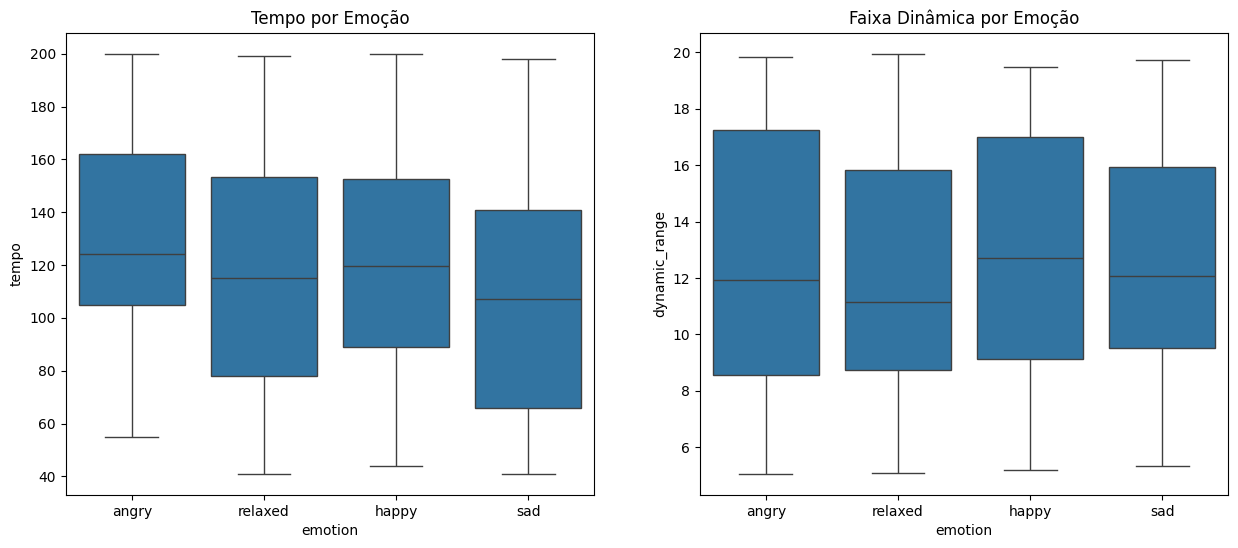

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(ax=axes[0], x='emotion', y='tempo', data=df)
axes[0].set_title('Tempo por Emoção')
sns.boxplot(ax=axes[1], x='emotion', y='dynamic_range', data=df)
axes[1].set_title('Faixa Dinâmica por Emoção')
plt.show()

Os boxplots mostram algumas diferenças nas distribuições de `tempo` e `dynamic_range` entre as emoções, sugerindo que essas características podem ajudar na classificação. Para os `MFCCs`, uma análise de componentes principais (PCA) pode ser útil para visualização.

## Hipótese 2: Existe uma correlação entre as características de áudio (`MFCCs`, `Chroma`) e os indicadores de emoção `valence` e `arousal`?

A matriz de correlação calculada anteriormente já nos ajuda a responder isso.

In [22]:
# Focando nas correlações de MFCCs e Chroma com valence e arousal
mfcc_cols = [f'mfcc_{i}' for i in range(1, 14)]
chroma_cols = [f'chroma_{i}' for i in range(1, 13)]

print("Correlação com Valence e Arousal:")
print(correlation_matrix.loc[mfcc_cols + chroma_cols, ['valence', 'arousal']])

Correlação com Valence e Arousal:
            valence   arousal
mfcc_1    -0.106841 -0.097551
mfcc_2    -0.003769  0.072282
mfcc_3     0.056772  0.057262
mfcc_4     0.045643  0.051406
mfcc_5     0.081849  0.100370
mfcc_6     0.156728 -0.010036
mfcc_7     0.055124  0.070531
mfcc_8    -0.113526 -0.001492
mfcc_9     0.015613  0.040660
mfcc_10    0.033639  0.042510
mfcc_11    0.028659  0.103796
mfcc_12   -0.134615  0.016568
mfcc_13    0.063465  0.015194
chroma_1   0.008499 -0.084008
chroma_2   0.026876  0.008947
chroma_3   0.011458  0.021616
chroma_4  -0.002468  0.110450
chroma_5  -0.061447 -0.078602
chroma_6   0.169938  0.073354
chroma_7   0.064556 -0.022768
chroma_8   0.037071 -0.113696
chroma_9  -0.075782 -0.142911
chroma_10 -0.104194  0.110087
chroma_11  0.059921 -0.020563
chroma_12 -0.070612 -0.118754


A tabela mostra que existem correlações (algumas fracas, outras moderadas) entre as características de áudio e os eixos de emoção, validando a hipótese.

## Hipótese 3: Composições com andamento (`tempo`) mais rápido tendem a ser classificadas como 'feliz' ou 'com raiva', enquanto as mais lentas são 'tristes' ou 'relaxadas'?

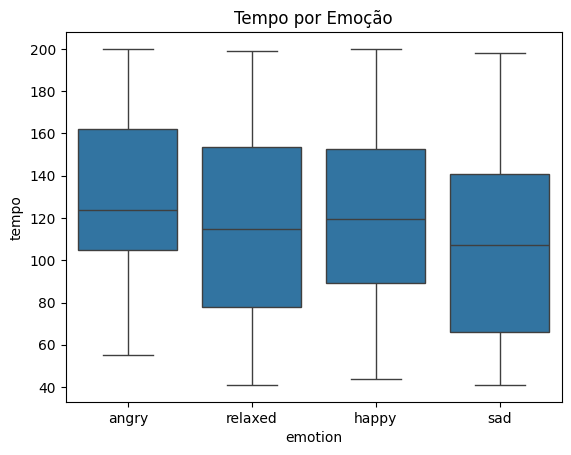

emotion
angry      129.852459
happy      123.652174
relaxed    117.428571
sad        108.243243
Name: tempo, dtype: float64


In [23]:
# Boxplot de tempo por emoção já foi mostrado na Hipótese 1
sns.boxplot(x='emotion', y='tempo', data=df)
plt.title('Tempo por Emoção')
plt.show()

print(df.groupby('emotion')['tempo'].mean())

Observando o boxplot e as médias de `tempo` por emoção, vemos que 'angry' e 'happy' tendem a ter um `tempo` médio mais alto do que 'sad' e 'relaxed', o que suporta a hipótese.

# Conclusão

A análise exploratória do dataset EmoPiano revelou padrões interessantes que conectam características musicais a emoções. O dataset é balanceado e limpo, o que facilita a modelagem.

As hipóteses levantadas foram em grande parte validadas:
1.  **Diferenças entre emoções:** Características como `tempo` e `dynamic_range` mostram distribuições distintas para diferentes emoções.
2.  **Correlação com `valence` e `arousal`:** As características de áudio (`MFCCs` e `Chroma`) apresentam correlações com os eixos emocionais, indicando seu potencial preditivo.
3.  **Relação `tempo`-emoção:** Músicas mais rápidas tendem a ser associadas a emoções de alta energia ('angry', 'happy'), enquanto as mais lentas a emoções de baixa energia ('sad', 'relaxed').

Este pré-processamento e análise inicial fornecem uma base sólida para a construção de um modelo de classificação de emoções musicais.